In [1]:
import os
os.listdir('/content')

['.config', 'archive.zip', 'sample_data']

In [2]:
!unzip /content/archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: meningioma/meningioma515.png  
  inflating: meningioma/meningioma516.png  
  inflating: meningioma/meningioma517.png  
  inflating: meningioma/meningioma518.png  
  inflating: meningioma/meningioma519.png  
  inflating: meningioma/meningioma52.png  
  inflating: meningioma/meningioma520.png  
  inflating: meningioma/meningioma521.png  
  inflating: meningioma/meningioma522.png  
  inflating: meningioma/meningioma523.png  
  inflating: meningioma/meningioma524.png  
  inflating: meningioma/meningioma525.png  
  inflating: meningioma/meningioma526.png  
  inflating: meningioma/meningioma527.png  
  inflating: meningioma/meningioma528.png  
  inflating: meningioma/meningioma529.png  
  inflating: meningioma/meningioma53.png  
  inflating: meningioma/meningioma530.png  
  inflating: meningioma/meningioma531.png  
  inflating: meningioma/meningioma532.png  
  inflating: meningioma/meningioma533.png  
  inflating: meningioma/men

In [3]:
import os
os.listdir('/content')

['.config',
 'archive.zip',
 'glioma',
 'pituitary',
 'meningioma',
 'no_tumor',
 'sample_data']

In [4]:
os.listdir('/content/meningioma')[:5]

['meningioma2049.jpg',
 'meningioma1780.jpg',
 'meningioma996.jpg',
 'meningioma739.jpg',
 'meningioma2332.jpg']

In [5]:
os.listdir('/content')

['.config',
 'archive.zip',
 'glioma',
 'pituitary',
 'meningioma',
 'no_tumor',
 'sample_data']

In [10]:
!mv /content/glioma /content/dataset/
!mv /content/meningioma /content/dataset/
!mv /content/no_tumor /content/dataset/
!mv /content/pituitary /content/dataset/

mv: cannot stat '/content/glioma': No such file or directory
mv: cannot stat '/content/meningioma': No such file or directory
mv: cannot stat '/content/no_tumor': No such file or directory
mv: cannot stat '/content/pituitary': No such file or directory


In [11]:
import os
os.listdir('/content/dataset')

['glioma', 'pituitary', 'meningioma', 'no_tumor']

In [12]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder('/content/dataset', transform=transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Total Images: 10560


In [13]:
from torch.utils.data import random_split

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 7391
Validation: 1584
Test: 1585


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 231
Validation batches: 50
Test batches: 50


In [15]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(weights="DEFAULT")

model.classifier[6] = nn.Linear(4096, 4)

model = model.to(device)

print(device)
print(model)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 169MB/s]


cuda
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=Tr

In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}, Accuracy: {acc:.2f}%")

Epoch 1/5, Loss: 110.5727, Accuracy: 81.14%
Epoch 2/5, Loss: 56.9007, Accuracy: 90.87%
Epoch 3/5, Loss: 37.5706, Accuracy: 93.76%
Epoch 4/5, Loss: 26.0824, Accuracy: 95.85%
Epoch 5/5, Loss: 17.5143, Accuracy: 97.27%


In [17]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 94.51104100946372


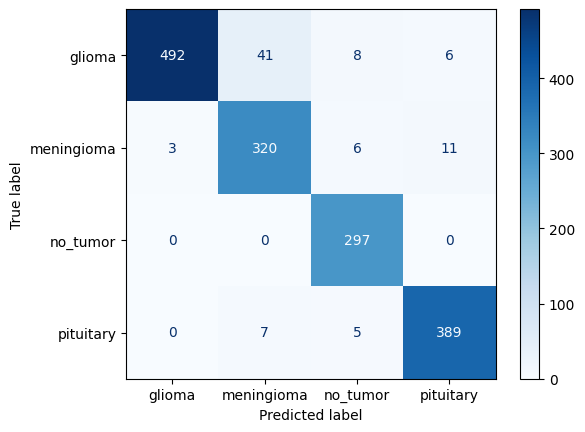

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
disp.plot(cmap='Blues')
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.99      0.90      0.94       547
  meningioma       0.87      0.94      0.90       340
    no_tumor       0.94      1.00      0.97       297
   pituitary       0.96      0.97      0.96       401

    accuracy                           0.95      1585
   macro avg       0.94      0.95      0.95      1585
weighted avg       0.95      0.95      0.95      1585



In [20]:
torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")

Model saved successfully!


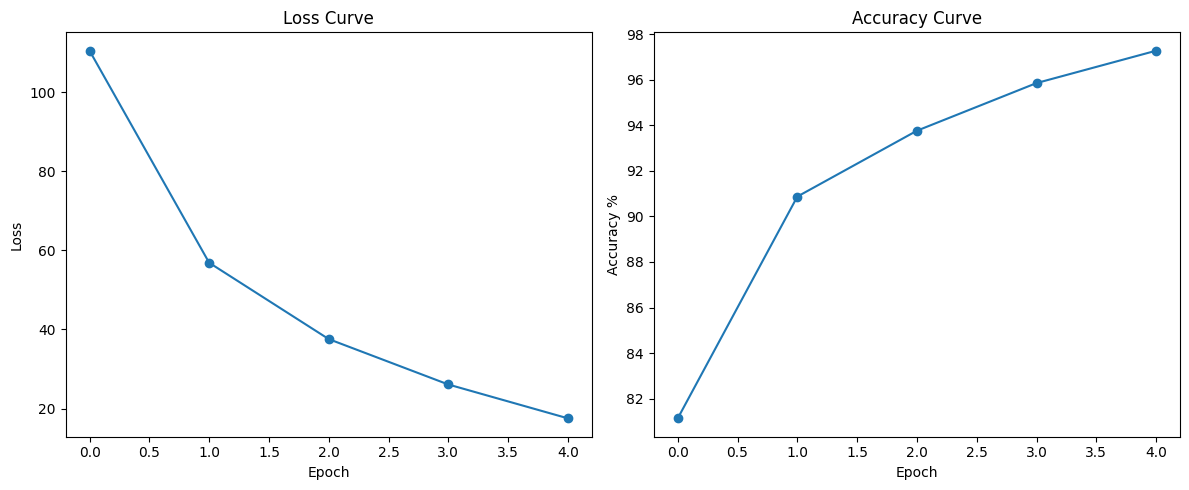

In [21]:
import matplotlib.pyplot as plt

train_losses = [110.57,56.90,37.57,26.08,17.51]
train_acc = [81.14,90.87,93.76,95.85,97.27]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_acc, marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")

plt.tight_layout()
plt.show()

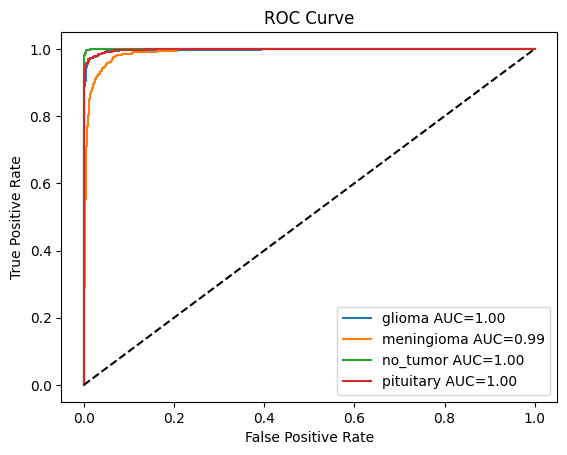

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_true = label_binarize(all_labels, classes=[0,1,2,3])

probs = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        p = torch.softmax(outputs, dim=1)
        probs.extend(p.cpu().numpy())

probs = np.array(probs)

for i in range(4):
    fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{dataset.classes[i]} AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_acc = 100 * correct / total
print("Validation Accuracy:", val_acc)

Validation Accuracy: 93.93939393939394
